In [14]:
import pandas as pd
import numpy as np


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [3]:
#load Data
df=pd.read_csv(r"C:\Users\dell\Downloads\BostonHousing.csv")

In [4]:
X=df.drop("medv",axis=1)
y=df["medv"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
#model
model=LinearRegression()
valid_indices=X_train.dropna().index
X_train_cleaned=X_train.loc[valid_indices]
y_train_cleaned=y_train.loc[valid_indices]

model.fit(X_train_cleaned,y_train_cleaned)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

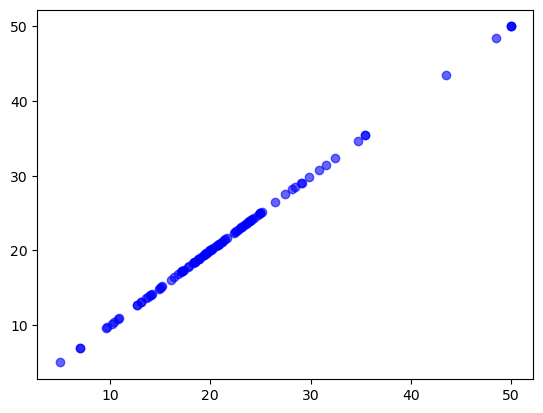

In [45]:
#scatter plot
plt.scatter(y_test,y_test,color="blue",alpha=0.6)


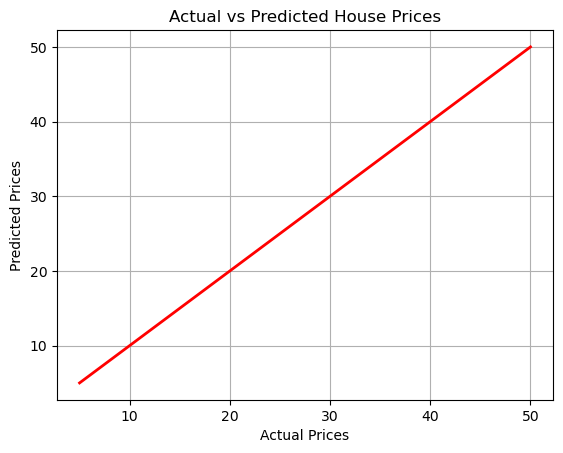

In [46]:
#ideal Line (perfect Prediction Lines)
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red",linewidth=2
)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

In [16]:
#practical No:4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [4]:
#load CSV File
data=pd.read_csv(r"C:\Users\dell\Downloads\BostonHousing.csv")
#Display First 5 rows
print(data.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [7]:
#separate Feature and Target
X=data.drop("medv",axis=1) #medv is target column
y=data["medv"]
#Impute missing values using mean strategy
imputer=SimpleImputer(strategy="mean")
X=pd.DataFrame(imputer.fit_transform(X),columns=X.columns)


In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=0
)

In [9]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)

In [17]:
#Mean Squared Error
train_mse=mean_squared_error(y_train,y_train_pred)
test_mse=mean_squared_error(y_test,y_test_pred)
#R2 Score
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

print("Training MSE:",train_mse)
print("Testing MSE:" ,test_mse)
print("Training R2 Score:",train_r2)
print("Testing R2 Score:" ,test_r2)

Training MSE: 19.391606535694894
Testing MSE: 33.4649759889145
Training R2 Score: 0.7722485406464419
Testing R2 Score: 0.5890259426012635


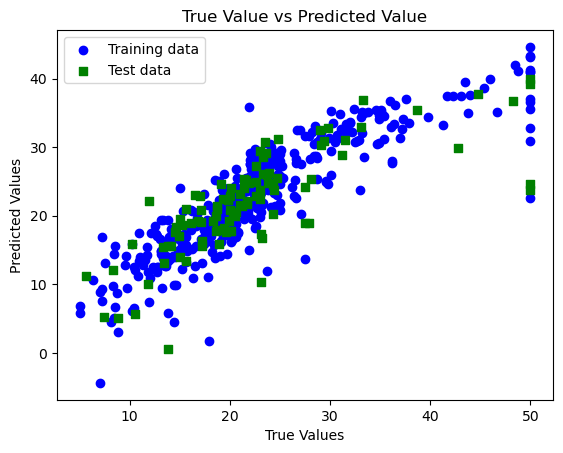

In [18]:
plt.scatter(y_train,y_train_pred,c="blue",marker="o",label="Training data")
plt.scatter(y_test,y_test_pred,c="green",marker='s',label="Test data")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True Value vs Predicted Value")
plt.legend(loc="upper left")
plt.show()